In [17]:
%pip install numba

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aeon 1.3.0 requires pandas<2.4.0,>=2.0.0, but you have pandas 3.0.0 which is incompatible.
aeon 1.3.0 requires scikit-learn<1.8.0,>=1.0.0, but you have scikit-learn 1.8.0 which is incompatible.
aeon 1.3.0 requires scipy<1.16.0,>=1.9.0, but you have scipy 1.17.0 which is incompatible.
tslearn 0.6.4 requires scikit-learn<1.7,>=1.3.2, but you have scikit-learn 1.8.0 which is incompatible.
tslearn 0.6.4 requires scipy<1.17,>=1.10.1, but you have scipy 1.17.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import polars as pl

parquet_path = r"C:\Users\wongb\Downloads\ratings-20260117-20260217.parquet"
df = pl.read_parquet(parquet_path)
df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification
i64,i64,str,str,datetime[ms],datetime[ms],datetime[ms],str,bool
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…",2021-02-04 10:08:21.128,2021-02-04 11:46:40.544,2026-02-01 14:36:13.314,"""NOT_HELPFUL""",false
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…",2021-02-04 10:08:21.128,2021-02-04 12:00:19.835,2026-02-01 14:36:04.345,"""NOT_HELPFUL""",false
1358604958673719296,1358464064322691078,"""456D1C422BA1A09690B986C8A1DBE7…","""FAB1117EE31D648BA7C11062F626AF…",2021-02-07 17:14:06.633,2021-02-08 02:33:58.465,2026-02-09 08:56:34.712,"""NOT_HELPFUL""",false
1358604958673719296,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""FAB1117EE31D648BA7C11062F626AF…",2021-02-07 17:14:06.633,2021-02-08 02:33:58.465,2026-02-09 00:51:34.502,"""NOT_HELPFUL""",false
1358844963216326659,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""605A405C64CC57A943D086CC80E5AC…",2021-02-07 17:14:06.633,2021-02-08 18:27:40.007,2026-02-09 00:51:18.076,"""NOT_HELPFUL""",false
…,…,…,…,…,…,…,…,…
1873623034814238798,1873417011294093499,"""C6C2E0DD1A03ADE2BC4C0F1870E01E…","""27AC2BCC9AF39C20C5ECC5D5A45F32…",2024-12-29 17:13:16.554,2024-12-30 06:51:56.390,2026-02-14 01:57:17.194,"""HELPFUL""",false
1873640928910692708,1873299604080607330,"""E26C94838DB911EDA747183982B930…","""7F16863BE3FB87264952B6B64F8082…",2024-12-29 09:26:44.493,2024-12-30 08:03:02.674,2026-02-14 20:22:12.656,"""NOT_HELPFUL""",false
1873642906235351150,1873299604080607330,"""E26C94838DB911EDA747183982B930…","""BE38D44A6D5F6828EE25798913696D…",2024-12-29 09:26:44.493,2024-12-30 08:10:54.106,2026-02-14 20:22:02.614,"""NOT_HELPFUL""",false


In [2]:
ratings_preprocessed_df = (
    df
    .with_columns(
        pl.col("ratingCreatedAt")
        .cast(pl.Datetime, strict=False)
        .alias("ratingCreatedAt_ts")
    )
    .group_by(["raterParticipantId", "ratedOnTweetId"])
.agg(
        pl.col("ratingCreatedAt_ts").min().alias("ratingCreatedAt_ts")
    )
    .sort(["raterParticipantId", "ratingCreatedAt_ts"])
.with_columns(
        pl.col("ratingCreatedAt_ts")
        .diff()
        .over("raterParticipantId")
        .dt.total_seconds()
        .alias("delta_seconds")
    )
    .with_columns(
        pl.when(pl.col("delta_seconds") > 0)
        .then(pl.col("delta_seconds").log())
        .otherwise(None)
        .alias("log_delta_seconds")
    )
)

ratings_preprocessed_df

raterParticipantId,ratedOnTweetId,ratingCreatedAt_ts,delta_seconds,log_delta_seconds
str,i64,datetime[μs],i64,f64
"""00002C7FD6E0080A69D0AB879C3D9B…",2016246745739546987,2026-01-28 20:47:22.321,null,null
"""00002C7FD6E0080A69D0AB879C3D9B…",2017578816177111423,2026-01-31 17:21:23.365,246841,12.4165
"""00002C7FD6E0080A69D0AB879C3D9B…",2018387895459983768,2026-02-02 22:44:01.605,192158,12.166073
"""00003D7D222733AE9D37A25B930204…",2012586343008755726,2026-01-18 15:41:27.835,null,null
"""00003D7D222733AE9D37A25B930204…",2012504826689520078,2026-01-18 19:28:17.202,13609,9.518487
…,…,…,…,…
"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…",2020604630657302841,2026-02-09 08:02:06.384,1041422,13.856098
"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…",2021784932818067904,2026-02-12 15:50:43.969,287317,12.568341
"""FFFFC46B8555A97065DB39F7D600C8…",2019467286298472468,2026-02-06 08:34:11.398,null,null


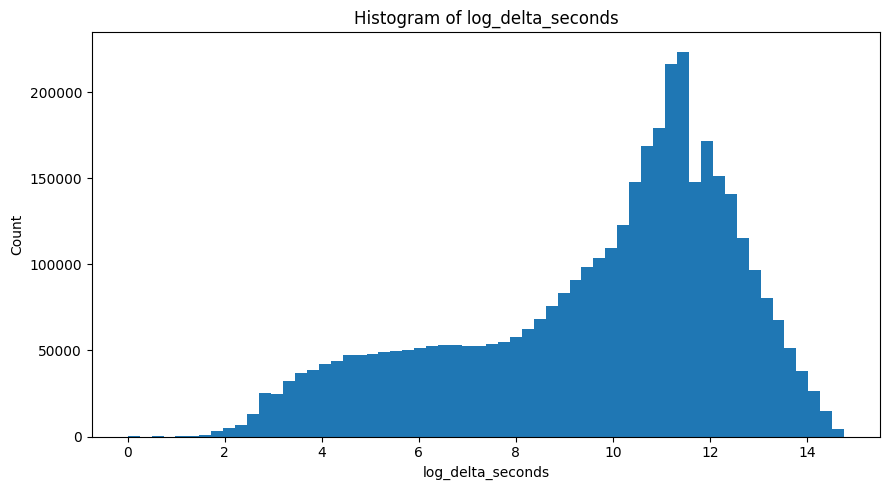

In [3]:
import matplotlib.pyplot as plt

if "ratings_preprocessed_df" not in globals():
    raise ValueError("`ratings_preprocessed_df` not found. Run Cell 3 first.")

values = (
    ratings_preprocessed_df
    .select("log_delta_seconds")
    .drop_nulls()
    .to_series()
    .to_numpy()
 )

plt.figure(figsize=(9, 5))
plt.hist(values, bins=60)
plt.title("Histogram of log_delta_seconds")
plt.xlabel("log_delta_seconds")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import polars as pl
from hmmlearn.hmm import GaussianHMM
from tqdm.auto import tqdm

# ── Configuration ─────────────────────────────────────────────────────────────
SAMPLE_MODE    = False
SAMPLE_RATERS  = 50_000
RANDOM_SEED    = 42
HMM_MAX_ITER   = 50
N_COMPONENTS   = 2

# ── Ensure preprocessed data (tweet-level, matching Cell 3) ──────────────────
if "ratings_preprocessed_df" not in globals():
    if "df" not in globals():
        raise ValueError("`df` not found. Run Cell 2 first.")
    ratings_preprocessed_df = (
        df
        .with_columns(
            pl.col("ratingCreatedAt")
            .cast(pl.Datetime, strict=False)
            .alias("ratingCreatedAt_ts")
        )
        .group_by(["raterParticipantId", "ratedOnTweetId"])
.agg(pl.col("ratingCreatedAt_ts").min().alias("ratingCreatedAt_ts"))
        .sort(["raterParticipantId", "ratingCreatedAt_ts"])
.with_columns(
            pl.col("ratingCreatedAt_ts")
            .diff()
            .over("raterParticipantId")
            .dt.total_seconds()
            .alias("delta_seconds")
        )
        .with_columns(
            pl.when(pl.col("delta_seconds") > 0)
            .then(pl.col("delta_seconds").log())
            .otherwise(None)
            .alias("log_delta_seconds")
        )
    )

progress = tqdm(total=6, desc="HMM session labeling", unit="step")

# ── Step 1: scope ─────────────────────────────────────────────────────────────
working_df = ratings_preprocessed_df
progress.set_postfix_str("scope data")
if SAMPLE_MODE:
    unique_raters = working_df.select("raterParticipantId").unique()
    n_sample = min(SAMPLE_RATERS, unique_raters.height)
    sampled = unique_raters.sample(n=n_sample, seed=RANDOM_SEED, shuffle=True)["raterParticipantId"].to_list()
    working_df = working_df.filter(pl.col("raterParticipantId").is_in(sampled))
    print(f"SAMPLE_MODE=True -> {n_sample:,} raters")
else:
    print("SAMPLE_MODE=False -> all raters")
progress.update(1)

# ── Step 2: sort + row index ──────────────────────────────────────────────────
progress.set_postfix_str("sort + index")
hmm_input_df = (
    working_df
    .sort(["raterParticipantId", "ratingCreatedAt_ts"])
.with_row_index("row_nr")
)
progress.update(1)

# ── Step 3: per-user observation sequences ────────────────────────────────────
progress.set_postfix_str("build observations")
valid_obs_df = hmm_input_df.filter(pl.col("log_delta_seconds").is_not_null())
if valid_obs_df.height == 0:
    raise ValueError("No valid log_delta_seconds observations found.")

X = valid_obs_df["log_delta_seconds"].to_numpy().reshape(-1, 1)

lengths = (
    valid_obs_df
    .group_by("raterParticipantId", maintain_order=True)
.agg(pl.len().alias("n"))["n"]
    .to_list()
)
if not lengths:
    raise ValueError("No user sequences found.")

print(f"  {len(lengths):,} user sequences  |  "
      f"total obs = {sum(lengths):,}  |  "
      f"median seq len = {int(np.median(lengths))}  |  "
      f"max seq len = {max(lengths)}")
progress.update(1)

# ── Step 4: initialise HMM directly from sequence data ───────────────────────
progress.set_postfix_str("init HMM")
hmm = GaussianHMM(
    n_components=N_COMPONENTS,
    covariance_type="diag",
    n_iter=HMM_MAX_ITER,
    random_state=RANDOM_SEED,
    init_params="stmc",
    params="stmc",
)
print("  Discovering HMM emissions directly from the per-user sequences")
progress.update(1)

# ── Step 5: fit over all per-user sequences ───────────────────────────────────
progress.set_postfix_str("fit HMM")
hmm.fit(X, lengths=lengths)
print(f"  Converged: {hmm.monitor_.converged}  "
      f"(iters used = {len(hmm.monitor_.history)})")
print(f"  Learned state means:  {hmm.means_.flatten().round(4).tolist()}")
print(f"  Learned transition matrix:\n{np.round(hmm.transmat_, 4)}")
progress.update(1)

# ── Step 6: decode states → session labels ────────────────────────────────────
progress.set_postfix_str("decode + label")
decoded_states = hmm.predict(X, lengths=lengths)
state_means    = hmm.means_.flatten()
in_session_state  = int(np.argmin(state_means))   # smaller gap → in-session
in_session_binary = (decoded_states == in_session_state).astype(np.int8)

state_df = pl.DataFrame({
    "row_nr":             valid_obs_df["row_nr"],
    "in_session_prev_gap": in_session_binary,
})

ratings_session_df = (
    hmm_input_df
    .join(state_df, on="row_nr", how="left")
    # promote session-starters: null/large-gap event whose next gap is small
    .with_columns(
        pl.col("in_session_prev_gap")
        .shift(-1)
        .over("raterParticipantId")
        .alias("next_gap_in_session")
    )
    .with_columns(
        pl.when(
            (pl.col("in_session_prev_gap") == 1) |
            (pl.col("next_gap_in_session") == 1)
        )
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
        .cast(pl.Int8)
        .alias("in_session")
    )
    # remove isolated singletons (in_session=1 but both neighbours are 0)
    .with_columns([
        pl.col("in_session").shift(1).over("raterParticipantId").fill_null(0).alias("prev_in_session"),
        pl.col("in_session").shift(-1).over("raterParticipantId").fill_null(0).alias("next_in_session"),
    ])
    .with_columns(
        pl.when(
            (pl.col("in_session") == 1) &
            (pl.col("prev_in_session") == 0) &
            (pl.col("next_in_session") == 0)
        )
        .then(pl.lit(0))
        .otherwise(pl.col("in_session"))
        .cast(pl.Int8)
        .alias("in_session")
    )
    .drop(["row_nr", "in_session_prev_gap", "next_gap_in_session",
           "prev_in_session", "next_in_session"])
)
progress.update(1)
progress.close()

print(f"\nIn-session state index: {in_session_state}  "
      f"(mean log_delta = {state_means[in_session_state]:.3f})")
in_session_frac = ratings_session_df["in_session"].mean()
print(f"Fraction of events labelled in-session: {in_session_frac:.2%}")

ratings_session_df


HMM session labeling:   0%|          | 0/6 [00:00<?, ?step/s]

SAMPLE_MODE=False -> all raters
  332,031 user sequences  |  total obs = 3,904,317  |  median seq len = 4  |  max seq len = 3296
  Discovering HMM emissions directly from the per-user sequences
  Converged: True  (iters used = 50)
  Learned state means:  [11.601, 7.5257]
  Learned transition matrix:
[[0.8044 0.1956]
 [0.1834 0.8166]]

In-session state index: 1  (mean log_delta = 7.526)
Fraction of events labelled in-session: 47.41%


raterParticipantId,ratedOnTweetId,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session
str,i64,datetime[μs],i64,f64,i8
"""00002C7FD6E0080A69D0AB879C3D9B…",2016246745739546987,2026-01-28 20:47:22.321,null,null,0
"""00002C7FD6E0080A69D0AB879C3D9B…",2017578816177111423,2026-01-31 17:21:23.365,246841,12.4165,0
"""00002C7FD6E0080A69D0AB879C3D9B…",2018387895459983768,2026-02-02 22:44:01.605,192158,12.166073,0
"""00003D7D222733AE9D37A25B930204…",2012586343008755726,2026-01-18 15:41:27.835,null,null,0
"""00003D7D222733AE9D37A25B930204…",2012504826689520078,2026-01-18 19:28:17.202,13609,9.518487,0
…,…,…,…,…,…
"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…",2020604630657302841,2026-02-09 08:02:06.384,1041422,13.856098,0
"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…",2021784932818067904,2026-02-12 15:50:43.969,287317,12.568341,0
"""FFFFC46B8555A97065DB39F7D600C8…",2019467286298472468,2026-02-06 08:34:11.398,null,null,0


In [5]:
ratings_session_df.write_csv("C:\\Users\\wongb\\user_trajectories_winter\\494-user-trajectories\\students\\benedict\\data\\behavior\\HMM_raw_per_tweet.csv")

In [6]:
ratings_session_df = pl.read_csv("C:\\Users\\wongb\\user_trajectories_winter\\494-user-trajectories\\students\\benedict\\data\\behavior\\HMM_raw_per_tweet.csv")
ratings_session_df

raterParticipantId,ratedOnTweetId,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session
str,i64,str,i64,f64,i64
"""00002C7FD6E0080A69D0AB879C3D9B…",2016246745739546987,"""2026-01-28T20:47:22.321000""",null,null,0
"""00002C7FD6E0080A69D0AB879C3D9B…",2017578816177111423,"""2026-01-31T17:21:23.365000""",246841,12.4165,0
"""00002C7FD6E0080A69D0AB879C3D9B…",2018387895459983768,"""2026-02-02T22:44:01.605000""",192158,12.166073,0
"""00003D7D222733AE9D37A25B930204…",2012586343008755726,"""2026-01-18T15:41:27.835000""",null,null,0
"""00003D7D222733AE9D37A25B930204…",2012504826689520078,"""2026-01-18T19:28:17.202000""",13609,9.518487,0
…,…,…,…,…,…
"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…",2020604630657302841,"""2026-02-09T08:02:06.384000""",1041422,13.856098,0
"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…",2021784932818067904,"""2026-02-12T15:50:43.969000""",287317,12.568341,0
"""FFFFC46B8555A97065DB39F7D600C8…",2019467286298472468,"""2026-02-06T08:34:11.398000""",null,null,0


In [7]:
if "ratings_session_df" not in globals():
    raise ValueError("`ratings_session_df` not found. Run Cell 5 first.")

import polars as pl

# 1) Overall label distribution
label_counts_df = (
    ratings_session_df
    .group_by("in_session")
    .agg(pl.len().alias("n"))
    .sort("in_session")
)

total_rows = ratings_session_df.height
in_session_rows = label_counts_df.filter(pl.col("in_session") == 1).select(pl.col("n").sum()).item() or 0
in_session_rate = in_session_rows / total_rows if total_rows else 0.0

# 2) Per-user stats
per_user_df = (
    ratings_session_df
    .group_by("raterParticipantId")
    .agg(
        pl.len().alias("n_events"),
        pl.col("in_session").sum().alias("n_in_session"),
    )
    .with_columns(
        (pl.col("n_in_session") / pl.col("n_events")).alias("in_session_rate"),
        (pl.col("n_in_session") > 0).cast(pl.Int8).alias("has_any_in_session"),
        (pl.col("n_in_session") == pl.col("n_events")).cast(pl.Int8).alias("all_events_in_session"),
    )
    .sort("n_events", descending=True)
)

n_users = per_user_df.height
n_users_any_in = per_user_df.filter(pl.col("has_any_in_session") == 1).height
n_users_none_in = per_user_df.filter(pl.col("has_any_in_session") == 0).height
n_users_all_in = per_user_df.filter(pl.col("all_events_in_session") == 1).height

avg_user_in_rate = per_user_df.select(pl.col("in_session_rate").mean()).item()
median_user_in_rate = per_user_df.select(pl.col("in_session_rate").median()).item()

user_rate_quantiles_df = per_user_df.select(
    pl.col("in_session_rate").quantile(0.10).alias("p10"),
    pl.col("in_session_rate").quantile(0.25).alias("p25"),
    pl.col("in_session_rate").quantile(0.50).alias("p50"),
    pl.col("in_session_rate").quantile(0.75).alias("p75"),
    pl.col("in_session_rate").quantile(0.90).alias("p90"),
)

user_mix_summary_df = pl.DataFrame(
    {
        "metric": [
            "n_users",
            "n_users_any_in_session",
            "n_users_no_in_session",
            "n_users_all_in_session",
            "share_users_any_in_session",
            "share_users_no_in_session",
            "share_users_all_in_session",
            "avg_user_in_session_rate",
            "median_user_in_session_rate",
        ],
        "value": [
            float(n_users),
            float(n_users_any_in),
            float(n_users_none_in),
            float(n_users_all_in),
            (n_users_any_in / n_users) if n_users else 0.0,
            (n_users_none_in / n_users) if n_users else 0.0,
            (n_users_all_in / n_users) if n_users else 0.0,
            float(avg_user_in_rate) if avg_user_in_rate is not None else 0.0,
            float(median_user_in_rate) if median_user_in_rate is not None else 0.0,
        ],
    }
)

# 3) First-event fallback sanity: how many first events ended up as in_session=1
first_event_df = (
    ratings_session_df
    .sort(["raterParticipantId", "ratingCreatedAt_ts"])
    .group_by("raterParticipantId", maintain_order=True)
    .first()
    .select("raterParticipantId", "in_session")
)

first_event_summary_df = first_event_df.select(
    pl.len().alias("n_users"),
    pl.col("in_session").sum().alias("n_first_event_in_session"),
    (pl.col("in_session").sum() / pl.len()).alias("first_event_in_session_rate"),
)

print(f"Rows: {total_rows:,}")
print(f"In-session rows: {in_session_rows:,} ({in_session_rate:.2%})")

print("\nLabel counts:")
display(label_counts_df)

print("\nRater-level summary:")
display(user_mix_summary_df)

print("\nRater in-session-rate quantiles:")
display(user_rate_quantiles_df)

print("\nFirst-event sanity:")
display(first_event_summary_df)

print("\nTop 10 users by number of events:")
display(per_user_df.head(10))

Rows: 4,388,429
In-session rows: 2,080,370 (47.41%)

Label counts:


in_session,n
i64,u32
0,2308059
1,2080370



Rater-level summary:


metric,value
str,f64
"""n_users""",484059.0
"""n_users_any_in_session""",141854.0
"""n_users_no_in_session""",342205.0
"""n_users_all_in_session""",9038.0
"""share_users_any_in_session""",0.293051
"""share_users_no_in_session""",0.706949
"""share_users_all_in_session""",0.018671
"""avg_user_in_session_rate""",0.144068
"""median_user_in_session_rate""",0.0



Rater in-session-rate quantiles:


p10,p25,p50,p75,p90
f64,f64,f64,f64,f64
0.0,0.0,0.0,0.222222,0.571429



First-event sanity:


n_users,n_first_event_in_session,first_event_in_session_rate
u32,i64,f64
484059,40569,0.08381



Top 10 users by number of events:


raterParticipantId,n_events,n_in_session,in_session_rate,has_any_in_session,all_events_in_session
str,u32,i64,f64,i8,i8
"""2E795F3F64D631134231C18AF09756…",3297,3297,1.0,1,1
"""14D7F5065E2F8F53F72F5325579AE2…",2969,2969,1.0,1,1
"""63B2C1FDD74AB973B3E178B14056D5…",2241,2241,1.0,1,1
"""E848DB71A10D211C7BC9CC031153C0…",2211,2211,1.0,1,1
"""0955AA84D076DBBD3981330BF71BBD…",2111,2111,1.0,1,1
"""D7FBAE9F9803A0FB30357F139CCEC8…",1955,1954,0.999488,1,0
"""A966340CA53AB1FE51516422935AF2…",1850,1850,1.0,1,1
"""6C17FA40B5C175176BC09E6FCDA67F…",1524,1523,0.999344,1,0
"""6107D93B0A0648AE0B04970B8DA48B…",1514,1514,1.0,1,1


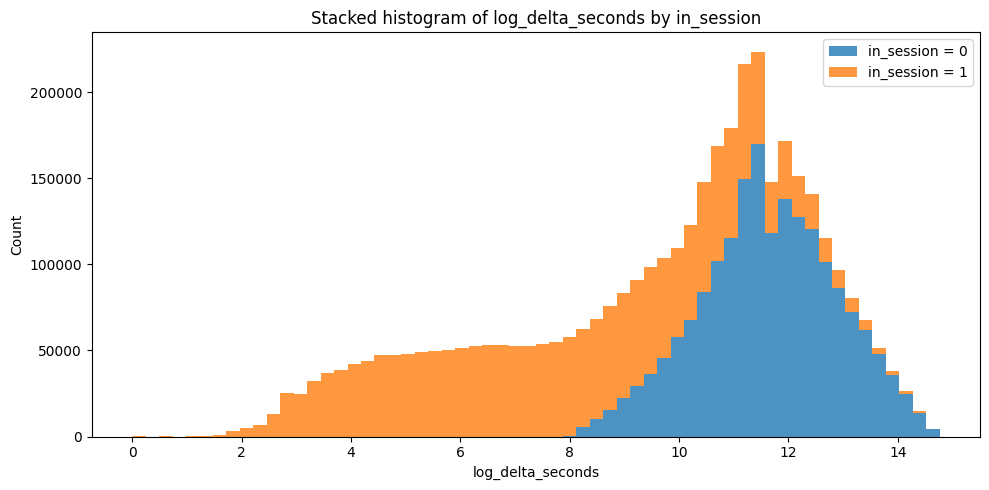

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

if "ratings_session_df" not in globals():
    raise ValueError("`ratings_session_df` not found. Run the session-labeling cell first.")

plot_df = ratings_session_df.select(["log_delta_seconds", "in_session"]).drop_nulls()

vals_0 = (
    plot_df
    .filter(pl.col("in_session") == 0)
    .select("log_delta_seconds")
    .to_series()
    .to_numpy()
 )
vals_1 = (
    plot_df
    .filter(pl.col("in_session") == 1)
    .select("log_delta_seconds")
    .to_series()
    .to_numpy()
 )

all_vals = np.concatenate([vals_0, vals_1]) if len(vals_0) and len(vals_1) else (vals_0 if len(vals_0) else vals_1)
bins = np.histogram_bin_edges(all_vals, bins=60)

plt.figure(figsize=(10, 5))
plt.hist([vals_0, vals_1], bins=bins, stacked=True, alpha=0.8, label=["in_session = 0", "in_session = 1"])
plt.title("Stacked histogram of log_delta_seconds by in_session")
plt.xlabel("log_delta_seconds")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
import polars as pl

if "ratings_session_df" not in globals():
    raise ValueError("`ratings_session_df` not found. Run Cell 6 first.")

base_df = ratings_session_df

if "ratingCreatedAt_ts" in base_df.columns:
    time_col = "ratingCreatedAt_ts"
    base_df = base_df.with_columns(pl.col(time_col).cast(pl.Datetime, strict=False))
elif "ratingCreatedAt" in base_df.columns:
    time_col = "ratingCreatedAt"
    base_df = base_df.with_columns(pl.col(time_col).cast(pl.Datetime, strict=False))
else:
    raise ValueError("Need either `ratingCreatedAt_ts` or `ratingCreatedAt` to order events chronologically.")

if "in_session" not in base_df.columns:
    raise ValueError("`in_session` column not found in dataset.")

session_labeled_df = (
    base_df
    .sort(["raterParticipantId", time_col])
    .with_columns(
        pl.col("in_session").cast(pl.Int8).alias("in_session")
    )
    .with_columns(
        (
            (pl.col("in_session") == 1)
            & (pl.col("in_session").shift(1).over("raterParticipantId").fill_null(0) == 0)
        )
        .cast(pl.Int32)
        .alias("session_start")
    )
    .with_columns(
        pl.col("session_start")
        .cum_sum()
        .over("raterParticipantId")
        .alias("user_session_id")
    )
    .with_columns(
        pl.when(pl.col("in_session") == 1)
        .then(pl.col("user_session_id"))
        .otherwise(None)
        .alias("user_session_id")
    )
    .drop("session_start")
)

session_labeled_df.select(
    "raterParticipantId",
    time_col,
    "in_session",
    "user_session_id",
).head(30)

raterParticipantId,ratingCreatedAt_ts,in_session,user_session_id
str,datetime[μs],i8,i32
"""00002C7FD6E0080A69D0AB879C3D9B…",2026-01-28 20:47:22.321,0,null
"""00002C7FD6E0080A69D0AB879C3D9B…",2026-01-31 17:21:23.365,0,null
"""00002C7FD6E0080A69D0AB879C3D9B…",2026-02-02 22:44:01.605,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-18 15:41:27.835,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-18 15:44:04.360,0,null
…,…,…,…
"""00003D7D222733AE9D37A25B930204…",2026-01-27 20:43:33.059,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-27 22:02:16.493,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-30 18:16:23.230,0,null


Headline metrics:


metric,value
str,f64
"""n_users""",484059.0
"""n_users_with_sessions""",239788.0
"""share_users_with_sessions""",0.495369
"""total_sessions""",759000.0
"""n_singleton_sessions""",0.0
"""share_singleton_sessions""",0.0
"""avg_sessions_per_user""",1.567991
"""median_sessions_per_user""",0.0
"""avg_session_length_events""",4.839241


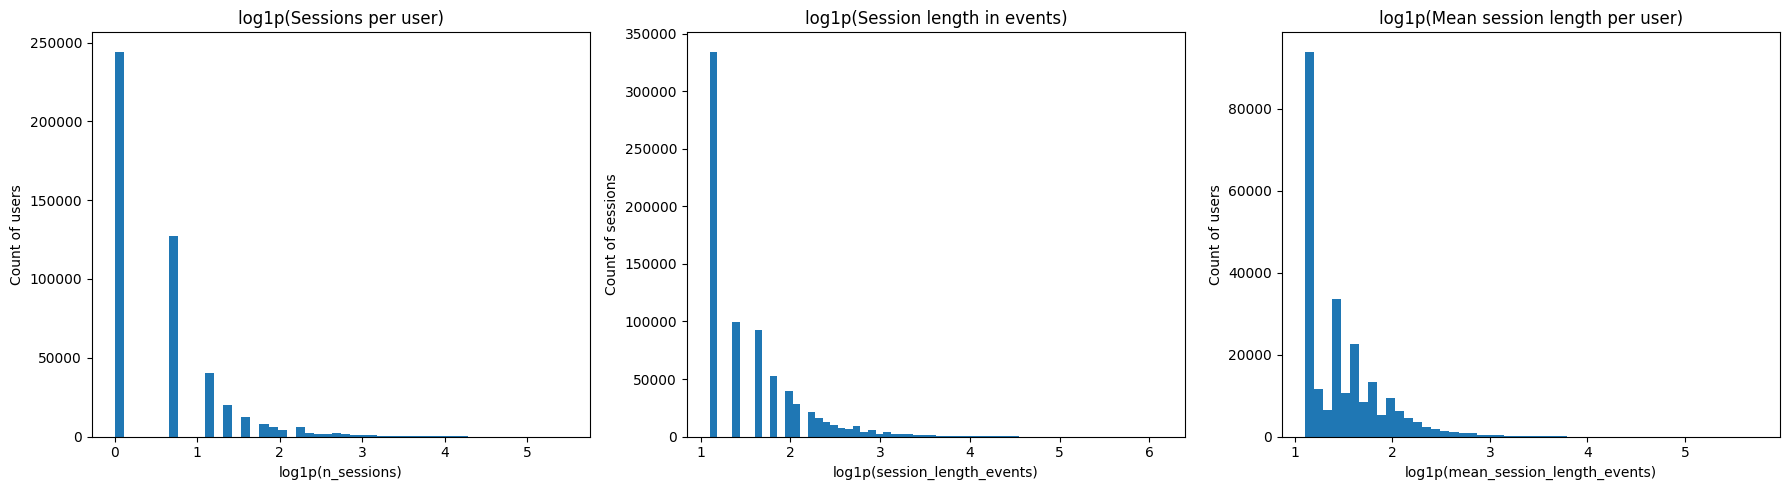

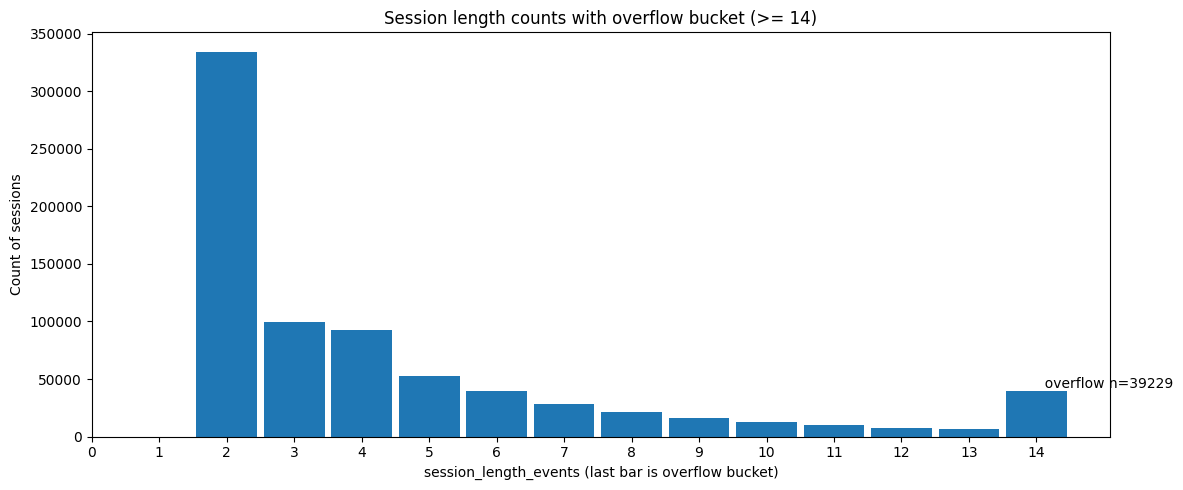

In [65]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

if "session_labeled_df" not in globals():
    raise ValueError("`session_labeled_df` not found. Run Cell 10 first.")

if "user_session_id" not in session_labeled_df.columns:
    raise ValueError("`user_session_id` not found in `session_labeled_df`.")

# Detect which timestamp column exists
if "ratingCreatedAt_ts" in session_labeled_df.columns:
    time_col = "ratingCreatedAt_ts"
elif "ratingCreatedAt" in session_labeled_df.columns:
    time_col = "ratingCreatedAt"
else:
    time_col = None

# -------- Session-level table --------
session_events_df = session_labeled_df.filter(pl.col("user_session_id").is_not_null())

session_level_df = (
    session_events_df
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.len().alias("session_length_events"),
        pl.col("log_delta_seconds").mean().alias("avg_log_delta_seconds_in_session"),
        pl.col("log_delta_seconds").median().alias("median_log_delta_seconds_in_session"),
        *( [
            pl.col(time_col).min().alias("session_start_ts"),
            pl.col(time_col).max().alias("session_end_ts"),
            (
                (pl.col(time_col).max().cast(pl.Int64) - pl.col(time_col).min().cast(pl.Int64))
                / 1_000_000
            ).alias("session_duration_seconds"),
        ] if time_col is not None else [] )
    )
    .sort(["raterParticipantId", "user_session_id"])
)

# -------- User-level summary --------
user_level_df = (
    session_labeled_df
    .group_by("raterParticipantId")
    .agg(
        pl.len().alias("n_total_events"),
        pl.col("in_session").sum().alias("n_in_session_events"),
        pl.col("user_session_id").drop_nulls().n_unique().alias("n_sessions"),
    )
    .with_columns(
        (pl.col("n_in_session_events") / pl.col("n_total_events")).alias("share_events_in_session"),
        pl.when(pl.col("n_sessions") > 0)
        .then(pl.col("n_in_session_events") / pl.col("n_sessions"))
        .otherwise(None)
        .alias("avg_session_length_events_per_user"),
    )
    .sort("n_sessions", descending=True)
)

# Enrich users with mean session length from session-level table
user_session_length_df = (
    session_level_df
    .group_by("raterParticipantId")
    .agg(
        pl.col("session_length_events").mean().alias("mean_session_length_events"),
        pl.col("session_length_events").median().alias("median_session_length_events"),
    )
)

user_level_df = user_level_df.join(user_session_length_df, on="raterParticipantId", how="left")

# -------- Headline metrics --------
n_users = user_level_df.height
n_users_with_sessions = user_level_df.filter(pl.col("n_sessions") > 0).height
total_sessions = session_level_df.height
n_singleton_sessions = session_level_df.filter(pl.col("session_length_events") == 1).height
share_singleton_sessions = (n_singleton_sessions / total_sessions) if total_sessions else 0.0
avg_sessions_per_user = user_level_df.select(pl.col("n_sessions").mean()).item()
median_sessions_per_user = user_level_df.select(pl.col("n_sessions").median()).item()
avg_session_length = session_level_df.select(pl.col("session_length_events").mean()).item() if total_sessions else None
median_session_length = session_level_df.select(pl.col("session_length_events").median()).item() if total_sessions else None

summary_metrics_df = pl.DataFrame(
    {
        "metric": [
            "n_users",
            "n_users_with_sessions",
            "share_users_with_sessions",
            "total_sessions",
            "n_singleton_sessions",
            "share_singleton_sessions",
            "avg_sessions_per_user",
            "median_sessions_per_user",
            "avg_session_length_events",
            "median_session_length_events",
        ],
        "value": [
            float(n_users),
            float(n_users_with_sessions),
            (n_users_with_sessions / n_users) if n_users else 0.0,
            float(total_sessions),
            float(n_singleton_sessions),
            float(share_singleton_sessions),
            float(avg_sessions_per_user) if avg_sessions_per_user is not None else 0.0,
            float(median_sessions_per_user) if median_sessions_per_user is not None else 0.0,
            float(avg_session_length) if avg_session_length is not None else 0.0,
            float(median_session_length) if median_session_length is not None else 0.0,
        ],
    }
)

print("Headline metrics:")
display(summary_metrics_df)

# -------- Graphs (log1p-transformed to reduce tail dominance) --------
sessions_per_user = user_level_df["n_sessions"].to_numpy()
session_lengths = session_level_df["session_length_events"].to_numpy() if total_sessions else np.array([])
mean_session_len_per_user = (
    user_level_df
    .select(pl.col("mean_session_length_events").drop_nulls())
    .to_series()
    .to_numpy()
)

log_sessions_per_user = np.log1p(sessions_per_user)
log_session_lengths = np.log1p(session_lengths) if len(session_lengths) > 0 else np.array([])
log_mean_session_len_per_user = np.log1p(mean_session_len_per_user) if len(mean_session_len_per_user) > 0 else np.array([])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(log_sessions_per_user, bins=50)
axes[0].set_title("log1p(Sessions per user)")
axes[0].set_xlabel("log1p(n_sessions)")
axes[0].set_ylabel("Count of users")

if len(log_session_lengths) > 0:
    axes[1].hist(log_session_lengths, bins=60)
else:
    axes[1].text(0.5, 0.5, "No sessions found", ha="center", va="center")
axes[1].set_title("log1p(Session length in events)")
axes[1].set_xlabel("log1p(session_length_events)")
axes[1].set_ylabel("Count of sessions")

if len(log_mean_session_len_per_user) > 0:
    axes[2].hist(log_mean_session_len_per_user, bins=50)
else:
    axes[2].text(0.5, 0.5, "No users with sessions", ha="center", va="center")
axes[2].set_title("log1p(Mean session length per user)")
axes[2].set_xlabel("log1p(mean_session_length_events)")
axes[2].set_ylabel("Count of users")

plt.tight_layout()
plt.show()

# -------- Additional clearer session-length count view --------
# Bucket very large session lengths into an overflow bucket so counts are easier to read.
if len(session_lengths) > 0:
    overflow_threshold = int(np.quantile(session_lengths, 0.95))
    overflow_threshold = max(overflow_threshold, 1)

    length_count_plot_df = (
        pl.DataFrame({"session_length_events": session_lengths})
        .with_columns(
            pl.when(pl.col("session_length_events") >= overflow_threshold)
            .then(pl.lit(overflow_threshold))
            .otherwise(pl.col("session_length_events"))
            .alias("length_bucket")
        )
        .group_by("length_bucket")
        .agg(pl.len().alias("n_sessions"))
        .sort("length_bucket")
    )

    x_vals = length_count_plot_df["length_bucket"].to_numpy()
    y_vals = length_count_plot_df["n_sessions"].to_numpy()
    overflow_n = int((session_lengths >= overflow_threshold).sum())

    plt.figure(figsize=(12, 5))
    plt.bar(x_vals, y_vals, width=0.9)
    plt.title(f"Session length counts with overflow bucket (>= {overflow_threshold})")
    plt.xlabel("session_length_events (last bar is overflow bucket)")
    plt.ylabel("Count of sessions")

    tick_step = max(1, int(overflow_threshold / 20))
    plt.xticks(np.arange(0, overflow_threshold + 1, tick_step))

    if overflow_n > 0:
        plt.text(
            overflow_threshold,
            y_vals[-1],
            f"  overflow n={overflow_n}",
            va="bottom",
            ha="left",
        )

    plt.tight_layout()
    plt.show()

Dirichlet interest summary:


metric,value
str,f64
"""n_sessions""",759000.0
"""n_sessions_with_interest""",695087.0
"""prop_sessions_with_interest""",0.915793
"""overall_prop_interest_ratings""",0.639172
"""avg_prop_interest_ratings_per_…",0.780556
"""median_prop_interest_ratings_p…",1.0
"""avg_interest_ratings_per_sessi…",3.093105
"""avg_ratings_per_session""",4.839241



Session-level interest quantiles:


p10,p25,p50,p75,p90
f64,f64,f64,f64,f64
0.25,0.6,1.0,1.0,1.0


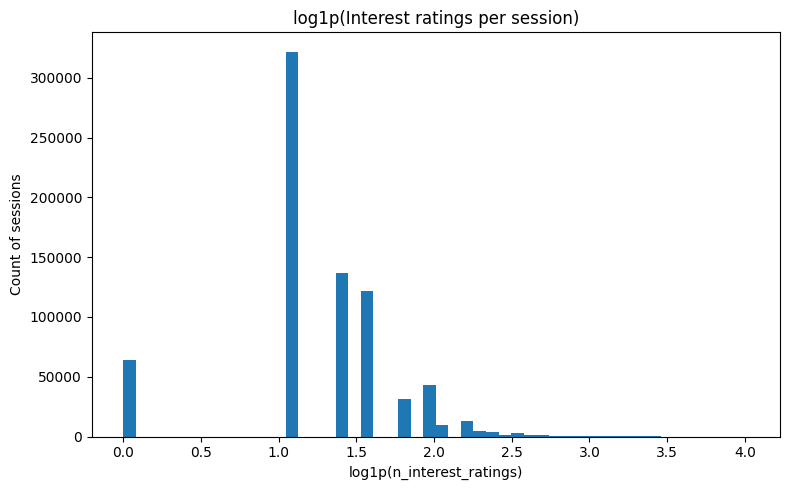


Preview of dirichlet_labeled_df:


noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,user_session_id,c_post,posterior_mean,interest
i64,i64,str,str,str,str,str,str,bool,datetime[μs],i64,f64,i8,i32,u32,f64,i8
2016534713742061788,2016246745739546987,"""00002C7FD6E0080A69D0AB879C3D9B…","""FD7979DE7F187DC14A4FDF8F557242…","""2026-01-27T20:27:38.894""","""2026-01-28T15:31:55.816""","""2026-01-28T20:47:22.321""","""HELPFUL""",false,2026-01-28 20:47:22.321,null,null,0,null,null,null,0
2017641230612451495,2017578816177111423,"""00002C7FD6E0080A69D0AB879C3D9B…","""2CE75633DDBFF074EE77E7DC582D7B…","""2026-01-31T12:40:49.235""","""2026-01-31T16:48:49.996""","""2026-01-31T17:21:23.365""","""HELPFUL""",false,2026-01-31 17:21:23.365,246841,12.4165,0,null,null,null,0
2018404224149717157,2018387895459983768,"""00002C7FD6E0080A69D0AB879C3D9B…","""54F0002E8A4890D64140C45F5D108C…","""2026-02-02T18:15:48.768""","""2026-02-02T19:20:41.831""","""2026-02-02T22:44:01.605""","""HELPFUL""",false,2026-02-02 22:44:01.605,192158,12.166073,0,null,null,null,0
2012648760455671942,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""B5A7C39C8965D9D8AF5CC38B994AAC…","""2026-01-17T18:02:30.876""","""2026-01-17T22:10:32.357""","""2026-01-18T15:41:27.835""","""NOT_HELPFUL""",false,2026-01-18 15:41:27.835,null,null,0,null,null,null,0
2012693431319990371,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""D174DF64F45A03029780F273B4335C…","""2026-01-17T18:02:30.876""","""2026-01-18T01:08:02.720""","""2026-01-18T15:44:04.360""","""HELPFUL""",false,2026-01-18 15:44:04.360,156,5.049856,0,null,null,null,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2015301912090878088,2015189340234645945,"""00003D7D222733AE9D37A25B930204…","""55AC18E8A73A60B03F155142ADCD2F…","""2026-01-24T22:25:53.776""","""2026-01-25T05:53:12.999""","""2026-01-25T21:56:38.660""","""HELPFUL""",false,2026-01-25 21:56:38.660,829,6.72022,0,null,null,null,0
2015570829703102599,2015464613547049370,"""00003D7D222733AE9D37A25B930204…",null,"""2026-01-25T16:39:44.048""",null,"""2026-01-26T00:10:07.710""","""NOT_HELPFUL""",false,2026-01-26 00:10:07.710,8009,8.988321,1,2,2,0.428571,1
2015577316534149474,2015464613547049370,"""00003D7D222733AE9D37A25B930204…","""225DB19C585AACCA62007BABB6E590…","""2026-01-25T16:39:44.048""","""2026-01-26T00:07:34.534""","""2026-01-26T00:10:13.253""","""HELPFUL""",false,2026-01-26 00:10:13.253,5,1.609438,1,2,2,0.428571,1


In [66]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

if "session_labeled_df" not in globals():
    raise ValueError("`session_labeled_df` not found. Run Cell 10 first.")

required_cols = ["raterParticipantId", "user_session_id", "ratedOnTweetId", "in_session"]
missing_cols = [c for c in required_cols if c not in session_labeled_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

alpha = 1.0

# Use only rows that are in a valid session for posterior calculation
session_rows_df = session_labeled_df.filter(pl.col("user_session_id").is_not_null())

# c_post: per user-session-post rating counts
post_counts_df = (
    session_rows_df
    .group_by(["raterParticipantId", "user_session_id", "ratedOnTweetId"])
.agg(
        pl.len().alias("c_post")
    )
)

# Session totals needed for Dirichlet posterior mean
session_totals_df = (
    post_counts_df
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.col("c_post").sum().alias("c_session"),
        pl.len().alias("k_posts"),
    )
)

# Posterior mean under symmetric Dirichlet(alpha=1)
post_posterior_df = (
    post_counts_df
    .join(session_totals_df, on=["raterParticipantId", "user_session_id"], how="left")
    .with_columns(
        ((pl.col("c_post") + alpha) / (pl.col("c_session") + alpha * pl.col("k_posts"))).alias("posterior_mean")
    )
)

# MAP post(s) within session with c_post >= 2
max_count_df = (
    post_posterior_df
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.col("c_post").max().alias("max_c_post")
    )
)

interest_posts_df = (
    post_posterior_df
    .join(max_count_df, on=["raterParticipantId", "user_session_id"], how="left")
    .filter(
        (pl.col("c_post") == pl.col("max_c_post"))
        & (pl.col("c_post") >= 2)
    )
    .select([
        "raterParticipantId",
        "user_session_id",
        "ratedOnTweetId",
        "c_post",
        "posterior_mean",
    ])
    .with_columns(pl.lit(1).cast(pl.Int8).alias("interest"))
)

# Attach posterior/count info and binary interest label back to row-level data
dirichlet_labeled_df = (
    session_labeled_df
    .join(
        post_posterior_df.select([
            "raterParticipantId",
            "user_session_id",
            "ratedOnTweetId",
            "c_post",
            "posterior_mean",
        ]),
        on=["raterParticipantId", "user_session_id", "ratedOnTweetId"],
        how="left",
    )
    .join(
        interest_posts_df.select(["raterParticipantId", "user_session_id", "ratedOnTweetId", "interest"]),
        on=["raterParticipantId", "user_session_id", "ratedOnTweetId"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("user_session_id").is_null())
        .then(0)
        .otherwise(pl.col("interest").fill_null(0))
        .cast(pl.Int8)
        .alias("interest")
    )
)

# Session-level stats for interest
session_interest_df = (
    dirichlet_labeled_df
    .filter(pl.col("user_session_id").is_not_null())
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.len().alias("n_ratings_in_session"),
        pl.col("interest").sum().alias("n_interest_ratings"),
    )
    .with_columns(
        (pl.col("n_interest_ratings") > 0).cast(pl.Int8).alias("session_has_interest"),
        (pl.col("n_interest_ratings") / pl.col("n_ratings_in_session")).alias("prop_interest_ratings"),
    )
)

n_sessions = session_interest_df.height
n_sessions_with_interest = session_interest_df.filter(pl.col("session_has_interest") == 1).height
prop_sessions_with_interest = (n_sessions_with_interest / n_sessions) if n_sessions else 0.0

overall_prop_interest_ratings = (
    dirichlet_labeled_df
    .filter(pl.col("user_session_id").is_not_null())
    .select(pl.col("interest").mean())
    .item()
    if n_sessions else 0.0
)

avg_prop_interest_ratings_per_session = session_interest_df.select(pl.col("prop_interest_ratings").mean()).item() if n_sessions else 0.0
median_prop_interest_ratings_per_session = session_interest_df.select(pl.col("prop_interest_ratings").median()).item() if n_sessions else 0.0
avg_interest_ratings_per_session = session_interest_df.select(pl.col("n_interest_ratings").mean()).item() if n_sessions else 0.0
avg_ratings_per_session = session_interest_df.select(pl.col("n_ratings_in_session").mean()).item() if n_sessions else 0.0

summary_interest_df = pl.DataFrame(
    {
        "metric": [
            "n_sessions",
            "n_sessions_with_interest",
            "prop_sessions_with_interest",
            "overall_prop_interest_ratings",
            "avg_prop_interest_ratings_per_session",
            "median_prop_interest_ratings_per_session",
            "avg_interest_ratings_per_session",
            "avg_ratings_per_session",
        ],
        "value": [
            float(n_sessions),
            float(n_sessions_with_interest),
            float(prop_sessions_with_interest),
            float(overall_prop_interest_ratings) if overall_prop_interest_ratings is not None else 0.0,
            float(avg_prop_interest_ratings_per_session) if avg_prop_interest_ratings_per_session is not None else 0.0,
            float(median_prop_interest_ratings_per_session) if median_prop_interest_ratings_per_session is not None else 0.0,
            float(avg_interest_ratings_per_session) if avg_interest_ratings_per_session is not None else 0.0,
            float(avg_ratings_per_session) if avg_ratings_per_session is not None else 0.0,
        ],
    }
)

print("Dirichlet interest summary:")
display(summary_interest_df)

print("\nSession-level interest quantiles:")
display(
    session_interest_df.select(
        pl.col("prop_interest_ratings").quantile(0.10).alias("p10"),
        pl.col("prop_interest_ratings").quantile(0.25).alias("p25"),
        pl.col("prop_interest_ratings").quantile(0.50).alias("p50"),
        pl.col("prop_interest_ratings").quantile(0.75).alias("p75"),
        pl.col("prop_interest_ratings").quantile(0.90).alias("p90"),
    )
)

# Graph: logged interest ratings per session
interest_counts = session_interest_df["n_interest_ratings"].to_numpy() if n_sessions else np.array([])
log_interest_counts = np.log1p(interest_counts) if len(interest_counts) > 0 else np.array([])

plt.figure(figsize=(8, 5))
if len(log_interest_counts) > 0:
    plt.hist(log_interest_counts, bins=50)
else:
    plt.text(0.5, 0.5, "No sessions found", ha="center", va="center")
plt.title("log1p(Interest ratings per session)")
plt.xlabel("log1p(n_interest_ratings)")
plt.ylabel("Count of sessions")
plt.tight_layout()
plt.show()

print("\nPreview of dirichlet_labeled_df:")
display(
    dirichlet_labeled_df.head(20)
)

Note-level raw delta summary:


total_ratings,total_notes,n_valid_note_deltas,avg_note_delta_seconds_overall,median_note_delta_seconds_overall
u32,u32,u32,f64,f64
6499635,114204,6385431,4468.590132,168.0



Note-size / within-note activity summary:


metric,value
str,f64
"""n_notes""",114204.0
"""n_notes_with_2plus_ratings""",86239.0
"""share_notes_with_2plus_ratings""",0.755131
"""avg_ratings_per_note""",56.912499
"""median_ratings_per_note""",10.0
"""p90_ratings_per_note""",134.0
"""p99_ratings_per_note""",724.0
"""avg_of_note_avg_delta_seconds""",53040.09528
"""median_of_note_avg_delta_secon…",5236.5



Preview of note_delta_df:


noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,note_delta_seconds
i64,i64,str,str,str,str,str,str,bool,datetime[μs],i64,f64,i64,i64
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…","""2021-02-04T10:08:21.128""","""2021-02-04T11:46:40.544""","""2026-02-01T14:36:13.314""","""NOT_HELPFUL""",false,2026-02-01 14:36:13.314,8,2.079442,1,null
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…","""2021-02-04T10:08:21.128""","""2021-02-04T12:00:19.835""","""2026-02-01T14:36:04.345""","""NOT_HELPFUL""",false,2026-02-01 14:36:04.345,13,2.564949,1,null
1358604958673719296,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T00:51:34.502""","""NOT_HELPFUL""",false,2026-02-09 00:51:34.502,16,2.772589,1,null
1358604958673719296,1358464064322691078,"""456D1C422BA1A09690B986C8A1DBE7…","""FAB1117EE31D648BA7C11062F626AF…","""2021-02-07T17:14:06.633""","""2021-02-08T02:33:58.465""","""2026-02-09T08:56:34.712""","""NOT_HELPFUL""",false,2026-02-09 08:56:34.712,57818,10.965055,1,29100
1358844963216326659,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""605A405C64CC57A943D086CC80E5AC…","""2021-02-07T17:14:06.633""","""2021-02-08T18:27:40.007""","""2026-02-09T00:51:18.076""","""NOT_HELPFUL""",false,2026-02-09 00:51:18.076,440090,12.994735,1,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
1421569650165370880,1421312166108581888,"""8635467C3284D81295EC243FE63D29…","""1BA344256D72112A8E254FADEF6963…","""2021-07-31T03:30:01.760""","""2021-07-31T20:33:10.744""","""2026-02-12T18:29:50.130""","""NOT_HELPFUL""",false,2026-02-12 18:29:50.130,316750,12.665868,0,null
1431744557738307588,1431669119208787974,"""F3EDDB1F065C028AF36DC098E5E1E7…","""2456B75D435E00EF7BF22530EFD2BD…","""2021-08-28T17:24:51.802""","""2021-08-28T22:24:37.754""","""2026-01-23T10:33:54.154""","""HELPFUL""",false,2026-01-23 10:33:54.154,27,3.295837,1,null
1431744557738307588,1431669119208787974,"""3AE03ADF4923AF6EA8E362C93173F5…","""2456B75D435E00EF7BF22530EFD2BD…","""2021-08-28T17:24:51.802""","""2021-08-28T22:24:37.754""","""2026-01-23T12:54:56.264""","""HELPFUL""",false,2026-01-23 12:54:56.264,28,3.332205,1,8462



Top 20 notes by number of ratings:


noteId,n_ratings_in_note,n_valid_deltas_in_note,avg_note_delta_seconds_in_note,median_note_delta_seconds_in_note
i64,u32,u32,f64,f64
2015141921954410626,8798,8797,168.446402,6.0
2016333600476528703,7225,7224,226.375,5.0
2012570670131995062,7030,7029,356.701522,4.0
2015520722970415150,6198,6197,198.126997,6.0
2015108784646152231,5799,5798,217.74474,4.0
…,…,…,…,…
2015102499670139185,4422,4421,334.30717,6.0
2014963647265611862,4298,4297,428.357924,6.0
2013693269079961830,4248,4247,420.333647,18.0


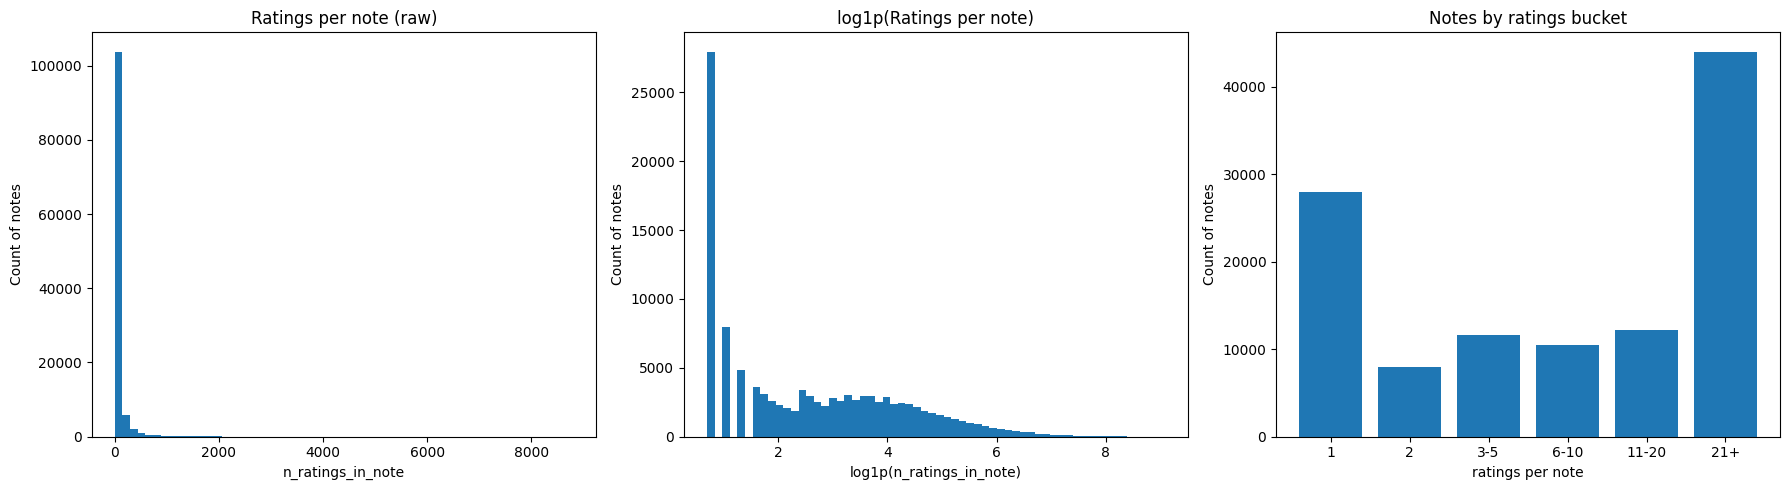

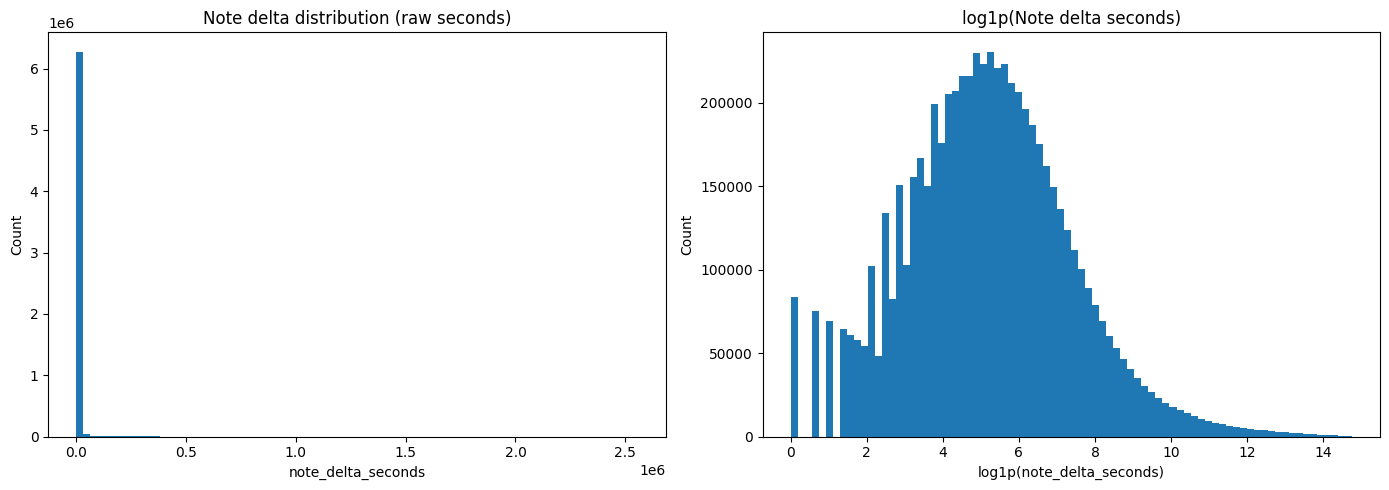

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

notes_preprocessed_df = (
    ratings_session_df
    .with_columns(
        pl.col("ratingCreatedAt")
        .cast(pl.Datetime, strict=False)
        .alias("ratingCreatedAt_ts")
    )
    .sort(["noteId", "ratingCreatedAt_ts"])
)

note_delta_df = (
    notes_preprocessed_df
    .with_columns(
        pl.col("ratingCreatedAt_ts")
        .diff()
        .over("noteId")
        .dt.total_seconds()
        .alias("note_delta_seconds")
    )
    .with_columns(
        pl.when(pl.col("note_delta_seconds").is_not_null())
        .then((pl.col("note_delta_seconds") + 1).log())
        .otherwise(None)
        .alias("log_note_delta_seconds")
    )
)

ratings_per_note_df = (
    note_delta_df
    .group_by("noteId")
    .agg(
        pl.len().alias("n_ratings_in_note"),
        pl.col("note_delta_seconds").drop_nulls().len().alias("n_valid_deltas_in_note"),
        pl.col("note_delta_seconds").mean().alias("avg_note_delta_seconds_in_note"),
        pl.col("note_delta_seconds").median().alias("median_note_delta_seconds_in_note"),
    )
)

n_notes = ratings_per_note_df.height
n_notes_multi_rating = ratings_per_note_df.filter(pl.col("n_ratings_in_note") >= 2).height
share_notes_multi_rating = (n_notes_multi_rating / n_notes) if n_notes else 0.0

note_delta_summary_df = note_delta_df.select(
    pl.len().alias("total_ratings"),
    pl.col("noteId").n_unique().alias("total_notes"),
    pl.col("note_delta_seconds").drop_nulls().len().alias("n_valid_note_deltas"),
    pl.col("note_delta_seconds").mean().alias("avg_note_delta_seconds_overall"),
    pl.col("note_delta_seconds").median().alias("median_note_delta_seconds_overall"),
)

note_size_summary_df = pl.DataFrame(
    {
        "metric": [
            "n_notes",
            "n_notes_with_2plus_ratings",
            "share_notes_with_2plus_ratings",
            "avg_ratings_per_note",
            "median_ratings_per_note",
            "p90_ratings_per_note",
            "p99_ratings_per_note",
            "avg_of_note_avg_delta_seconds",
            "median_of_note_avg_delta_seconds",
        ],
        "value": [
            float(n_notes),
            float(n_notes_multi_rating),
            float(share_notes_multi_rating),
            float(ratings_per_note_df.select(pl.col("n_ratings_in_note").mean()).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("n_ratings_in_note").median()).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("n_ratings_in_note").quantile(0.90)).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("n_ratings_in_note").quantile(0.99)).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("avg_note_delta_seconds_in_note").mean()).item() or 0.0),
            float(ratings_per_note_df.select(pl.col("avg_note_delta_seconds_in_note").median()).item() or 0.0),
        ],
    }
)

print("Note-level raw delta summary:")
display(note_delta_summary_df)

print("\nNote-size / within-note activity summary:")
display(note_size_summary_df)

print("\nPreview of note_delta_df:")
display(
    note_delta_df.head(30)
)

print("\nTop 20 notes by number of ratings:")
display(
    ratings_per_note_df.sort("n_ratings_in_note", descending=True).head(20)
)

ratings_counts = ratings_per_note_df["n_ratings_in_note"].to_numpy()
delta_vals = (
    note_delta_df
    .select("note_delta_seconds")
    .drop_nulls()
    .to_series()
    .to_numpy()
)
log_delta_vals = (
    note_delta_df
    .select("log_note_delta_seconds")
    .drop_nulls()
    .to_series()
    .to_numpy()
)

if len(ratings_counts) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(ratings_counts, bins=60)
    axes[0].set_title("Ratings per note (raw)")
    axes[0].set_xlabel("n_ratings_in_note")
    axes[0].set_ylabel("Count of notes")

    log_counts = np.log1p(ratings_counts)
    axes[1].hist(log_counts, bins=60)
    axes[1].set_title("log1p(Ratings per note)")
    axes[1].set_xlabel("log1p(n_ratings_in_note)")
    axes[1].set_ylabel("Count of notes")

    bucket_df = (
        ratings_per_note_df
        .with_columns(
            pl.when(pl.col("n_ratings_in_note") == 1).then(pl.lit("1"))
            .when(pl.col("n_ratings_in_note") == 2).then(pl.lit("2"))
            .when(pl.col("n_ratings_in_note").is_between(3, 5)).then(pl.lit("3-5"))
            .when(pl.col("n_ratings_in_note").is_between(6, 10)).then(pl.lit("6-10"))
            .when(pl.col("n_ratings_in_note").is_between(11, 20)).then(pl.lit("11-20"))
            .otherwise(pl.lit("21+"))
            .alias("ratings_bucket")
        )
        .group_by("ratings_bucket")
        .agg(pl.len().alias("n_notes"))
    )

    bucket_order = ["1", "2", "3-5", "6-10", "11-20", "21+"]
    bucket_map = {
        row["ratings_bucket"]: row["n_notes"]
        for row in bucket_df.iter_rows(named=True)
    }
    bucket_vals = [bucket_map.get(b, 0) for b in bucket_order]

    axes[2].bar(bucket_order, bucket_vals)
    axes[2].set_title("Notes by ratings bucket")
    axes[2].set_xlabel("ratings per note")
    axes[2].set_ylabel("Count of notes")

    plt.tight_layout()
    plt.show()

if len(delta_vals) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(delta_vals, bins=80)
    axes[0].set_title("Note delta distribution (raw seconds)")
    axes[0].set_xlabel("note_delta_seconds")
    axes[0].set_ylabel("Count")

    axes[1].hist(log_delta_vals, bins=80)
    axes[1].set_title("log1p(Note delta seconds)")
    axes[1].set_xlabel("log_note_delta_seconds")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

Cluster centroids (original scale): 7.1, 90.9
Natural break cutoff: 49 ratings

Sparse pool    (2 to 49):  59,170 notes
Candidate pool (49+):       27,069 notes


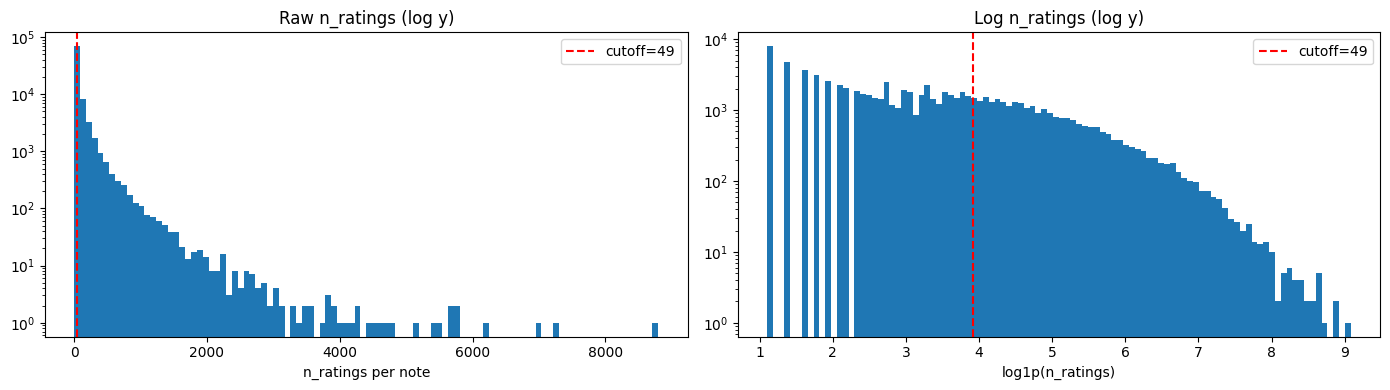

In [23]:
import numpy as np
import polars as pl
from sklearn.cluster import KMeans

# ── 1. get per-note rating counts ─────────────────────────────────────────────
note_counts = (
    ratings_session_df
    .group_by("noteId")
    .agg(pl.len().alias("n_ratings"))
    .filter(pl.col("n_ratings") > 1)  # drop singletons
)

n = note_counts["n_ratings"].to_numpy().reshape(-1, 1)
log_n = np.log1p(n)

# ── 2. jenks via 1D k-means (k=2 since you have 2 peaks) ─────────────────────
km = KMeans(n_clusters=2, random_state=42, n_init=20)
km.fit(log_n)

# cutoff = midpoint between the two centroids in original space
centroids = np.sort(np.expm1(km.cluster_centers_.flatten()))
cutoff = int(np.round(np.mean(centroids)))

print(f"Cluster centroids (original scale): {centroids[0]:.1f}, {centroids[1]:.1f}")
print(f"Natural break cutoff: {cutoff} ratings")

# ── 3. sanity check: how many notes in each cohort? ───────────────────────────
sparse    = (note_counts["n_ratings"] <= cutoff).sum()
candidate = (note_counts["n_ratings"] >  cutoff).sum()
print(f"\nSparse pool    (2 to {cutoff}):  {sparse:,} notes")
print(f"Candidate pool ({cutoff}+):       {candidate:,} notes")

# ── 4. plot to verify the break makes sense ───────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(n, bins=100, log=True)
axes[0].axvline(cutoff, color='red', linestyle='--', label=f'cutoff={cutoff}')
axes[0].set_xlabel("n_ratings per note")
axes[0].set_title("Raw n_ratings (log y)")
axes[0].legend()

axes[1].hist(log_n, bins=100, log=True)
axes[1].axvline(np.log1p(cutoff), color='red', linestyle='--', label=f'cutoff={cutoff}')
axes[1].set_xlabel("log1p(n_ratings)")
axes[1].set_title("Log n_ratings (log y)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:

note_counts_df = (
    note_delta_df
    .group_by("noteId")
    .agg(pl.len().alias("n_ratings"))
    .sort("n_ratings", descending=True)
)

print("Per-note rating counts (for Cell 16 filtering):")
display(note_counts_df.head(20))

Per-note rating counts (for Cell 16 filtering):


noteId,n_ratings
i64,u32
2015141921954410626,8798
2016333600476528703,7225
2012570670131995062,7030
2015520722970415150,6198
2015108784646152231,5799
…,…
2015102499670139185,4422
2014963647265611862,4298
2013693269079961830,4248


In [25]:
# Stratify notes by total rating count (from note_counts_df)
forgotten_notes_df = note_counts_df.filter(pl.col("n_ratings") == 1)
sparse_notes_df = note_counts_df.filter(pl.col("n_ratings").is_between(2, 4))
candidate_notes_df = note_counts_df.filter(pl.col("n_ratings") >= 5)

# Note ID lists for applying to row-level note_delta_df
forgotten_note_ids = forgotten_notes_df["noteId"].to_list()
sparse_note_ids = sparse_notes_df["noteId"].to_list()
candidate_note_ids = candidate_notes_df["noteId"].to_list()

# Row-level datasets from note_delta_df using those note sets
forgotten_df = note_delta_df.filter(pl.col("noteId").is_in(forgotten_note_ids))
sparse_df = note_delta_df.filter(pl.col("noteId").is_in(sparse_note_ids))
candidate_df = note_delta_df.filter(pl.col("noteId").is_in(candidate_note_ids))

print("Note-count category sizes (number of notes):")
display(
    pl.DataFrame({
        "category": ["forgotten (1)", "sparse (2-20)", "candidate (21+)"],
        "n_notes": [forgotten_notes_df.height, sparse_notes_df.height, candidate_notes_df.height],
        "n_rows_in_note_delta_df": [forgotten_df.height, sparse_df.height, candidate_df.height],
    })
)
forgotten_df

Note-count category sizes (number of notes):


category,n_notes,n_rows_in_note_delta_df
str,i64,i64
"""forgotten (1)""",27965,27965
"""sparse (2-20)""",16460,45017
"""candidate (21+)""",69779,6426653


noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session,note_delta_seconds
i64,i64,str,str,str,str,str,str,bool,datetime[μs],i64,f64,i64,i64
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…","""2021-02-04T10:08:21.128""","""2021-02-04T11:46:40.544""","""2026-02-01T14:36:13.314""","""NOT_HELPFUL""",false,2026-02-01 14:36:13.314,8,2.079442,1,null
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…","""2021-02-04T10:08:21.128""","""2021-02-04T12:00:19.835""","""2026-02-01T14:36:04.345""","""NOT_HELPFUL""",false,2026-02-01 14:36:04.345,13,2.564949,1,null
1365312734712238082,1362774562769879044,"""B19EC3432CD4CFEC68CA1C301B34E4…","""E9FA3618E5EF5961394CD4D435DC2E…","""2021-02-19T14:42:29.548""","""2021-02-26T14:48:16.897""","""2026-02-13T20:06:42.891""","""NOT_HELPFUL""",false,2026-02-13 20:06:42.891,5,1.609438,1,null
1368576992971534343,1362774562769879044,"""B19EC3432CD4CFEC68CA1C301B34E4…","""54AE76555042121BFD0A9800E502E2…","""2021-02-19T14:42:29.548""","""2021-03-07T14:59:16.711""","""2026-02-13T20:06:36.933""","""NOT_HELPFUL""",false,2026-02-13 20:06:36.933,5956,8.692154,1,null
1383882709454315528,842392085168824320,"""9A2D57C249B9C52F5F90481C006538…","""9FAA243AA35F6C4BE161A682DA5E29…","""2017-03-16T15:08:18.649""","""2021-04-18T20:38:43.888""","""2026-02-10T21:45:29.217""","""HELPFUL""",false,2026-02-10 21:45:29.217,41,3.713572,1,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023244265745175011,2023097795809362050,"""138A5CC86C485C6A9D3CDB8B03E265…","""0FF5650CCAE81A89BD976B9EABF265…","""2026-02-15T18:11:16.517""","""2026-02-16T03:53:17.671""","""2026-02-16T03:54:46.500""","""HELPFUL""",false,2026-02-16 03:54:46.500,570098,13.253564,0,null
2023244399657030064,2023157422366560260,"""673F3E152DF25D2A24EDBB7867FAA8…","""F75B04680623CD9A452496D4AB69A2…","""2026-02-15T22:08:12.596""","""2026-02-16T03:55:26.102""","""2026-02-16T03:59:53.712""","""HELPFUL""",false,2026-02-16 03:59:53.712,155,5.043425,0,null
2023244425455976896,2022740887026180430,"""EB2176A2C2250A3F25AF44B60B3126…","""D6451D0AA39C4C7700371748147442…","""2026-02-14T18:33:02.832""","""2026-02-16T03:53:55.749""","""2026-02-16T03:59:58.682""","""NOT_HELPFUL""",false,2026-02-16 03:59:58.682,434536,12.982034,0,null


Notes with baseline: 69,779
Global fallback — mean: 5.502  std: 1.913

Label breakdown:
  coordinated (<=7s): 517,648  (8.1%)
  burst (z>1.0):       857,940  (13.5%)
  organic:            4,981,286  (78.4%)
  total swarm:        1,375,588  (21.6%)

Note-level summary:
  notes with any swarm:        67,544
  notes with swarm_rate > 0.5: 86
  median swarm_rate:           0.167


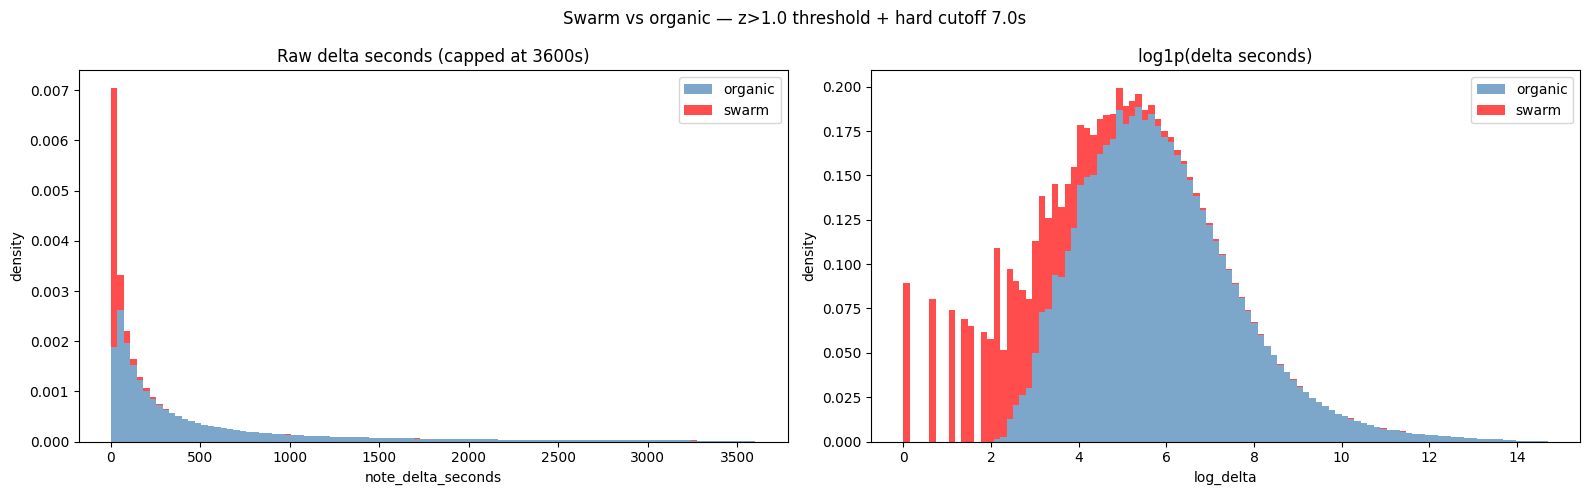

noteId,n_gaps,n_swarm,swarm_rate,max_swarm_score,n_coordinated,n_burst
i64,u32,i64,f64,f64,u32,u32
2015487955633426573,776,753,0.970361,1.0,753,0
2019216683785986383,676,629,0.930473,1.0,629,0
2015108843135783264,515,459,0.891262,1.0,459,0
2019235499509182574,767,664,0.865711,1.0,664,0
2015497096615374922,1372,1178,0.858601,1.0,1137,41
…,…,…,…,…,…,…
2014012972897607973,91,61,0.67033,1.0,55,6
2012570670131995062,7029,4640,0.660122,1.0,4316,324
2015489740590760245,596,389,0.652685,1.0,321,68


In [47]:
import numpy as np
import polars as pl
from scipy.special import expit

HARD_CUTOFF_S = 7.0

# ── 1. compute note baseline excluding sub-7s ─────────────────────────────────
global_std = float(
    candidate_df
    .filter(pl.col("note_delta_seconds") > HARD_CUTOFF_S)
    ["note_delta_seconds"]
    .log1p()
    .std()
)
global_mean = float(
    candidate_df
    .filter(pl.col("note_delta_seconds") > HARD_CUTOFF_S)
    ["note_delta_seconds"]
    .log1p()
    .mean()
)

note_baseline_df = (
    candidate_df
    .filter(pl.col("note_delta_seconds").is_not_null())
    .filter(pl.col("note_delta_seconds") > HARD_CUTOFF_S)
    .with_columns(pl.col("note_delta_seconds").log1p().alias("log_delta"))
    .group_by("noteId")
    .agg([
        pl.col("log_delta").mean().alias("note_mean_log_delta"),
        pl.col("log_delta").std().alias("note_std_log_delta"),
        pl.col("log_delta").count().alias("n_organic_gaps"),
    ])
)

# fix nulls in Python where we have full control
note_baseline = {}
for row in note_baseline_df.iter_rows(named=True):
    mean = row["note_mean_log_delta"]
    std  = row["note_std_log_delta"]
    note_baseline[row["noteId"]] = (
        mean if mean is not None else global_mean,
        std  if (std is not None and std > 0) else global_std,
    )

print(f"Notes with baseline: {len(note_baseline):,}")
print(f"Global fallback — mean: {global_mean:.3f}  std: {global_std:.3f}")

# ── 2. score all gaps ─────────────────────────────────────────────────────────
rows = (
    candidate_df
    .filter(pl.col("note_delta_seconds").is_not_null())
    .filter(pl.col("note_delta_seconds") >= 0)
    .sort(["noteId", "ratingCreatedAt"])
    .to_dicts()
)

note_mean_arr = np.array([
    note_baseline.get(r["noteId"], (global_mean, global_std))[0]
    for r in rows
], dtype=np.float64)

note_std_arr = np.array([
    note_baseline.get(r["noteId"], (global_mean, global_std))[1]
    for r in rows
], dtype=np.float64)

gap_arr       = np.array([r["note_delta_seconds"] for r in rows], dtype=np.float64)
log_delta_arr = np.log1p(gap_arr)

z_arr         = (note_mean_arr - log_delta_arr) / note_std_arr  # positive = faster than baseline

# ── 3. hybrid labeling ────────────────────────────────────────────────────────
is_coordinated = gap_arr <= HARD_CUTOFF_S

# z > 1 threshold: gap must be >1 std dev faster than note baseline
Z_THRESHOLD = 1.0
swarm_label  = np.where(
    is_coordinated,
    1,
    (z_arr > Z_THRESHOLD).astype(np.int8)
).astype(np.int8)

# smooth score: sigmoid shifted so z=Z_THRESHOLD maps to 0.5
swarm_score  = np.where(
    is_coordinated,
    1.0,
    expit(z_arr - Z_THRESHOLD)
)

swarm_type   = np.where(
    is_coordinated, "coordinated",
    np.where(swarm_label == 1, "burst", "organic")
)

# ── 4. build output df ────────────────────────────────────────────────────────
scored_df = pl.DataFrame({
    "noteId":              [r["noteId"]           for r in rows],
    "ratingCreatedAt":     [r["ratingCreatedAt"]  for r in rows],
    "note_delta_seconds":  gap_arr.tolist(),
    "log_delta":           log_delta_arr.tolist(),
    "note_mean_log_delta": note_mean_arr.tolist(),
    "note_std_log_delta":  note_std_arr.tolist(),
    "z_score":             z_arr.tolist(),
    "swarm_score":         swarm_score.tolist(),
    "swarm_label":         swarm_label.tolist(),
    "swarm_type":          swarm_type.tolist(),
})

# ── 5. summary ────────────────────────────────────────────────────────────────
print(f"\nLabel breakdown:")
print(f"  coordinated (<=7s): {is_coordinated.sum():,}  "
      f"({is_coordinated.mean()*100:.1f}%)")
print(f"  burst (z>{Z_THRESHOLD}):       "
      f"{((~is_coordinated) & (swarm_label==1)).sum():,}  "
      f"({((~is_coordinated) & (swarm_label==1)).mean()*100:.1f}%)")
print(f"  organic:            {(swarm_label==0).sum():,}  "
      f"({(swarm_label==0).mean()*100:.1f}%)")
print(f"  total swarm:        {swarm_label.sum():,}  "
      f"({swarm_label.mean()*100:.1f}%)")

# ── 6. note-level summary ─────────────────────────────────────────────────────
note_summary_df = (
    scored_df
    .group_by("noteId")
    .agg([
        pl.len().alias("n_gaps"),
        pl.col("swarm_label").sum().alias("n_swarm"),
        pl.col("swarm_label").mean().alias("swarm_rate"),
        pl.col("swarm_score").max().alias("max_swarm_score"),
        (pl.col("swarm_type") == "coordinated").sum().alias("n_coordinated"),
        (pl.col("swarm_type") == "burst").sum().alias("n_burst"),
    ])
    .sort("swarm_rate", descending=True)
)

print(f"\nNote-level summary:")
print(f"  notes with any swarm:        "
      f"{(note_summary_df['n_swarm'] > 0).sum():,}")
print(f"  notes with swarm_rate > 0.5: "
      f"{(note_summary_df['swarm_rate'] > 0.5).sum():,}")
print(f"  median swarm_rate:           "
      f"{note_summary_df['swarm_rate'].median():.3f}")

# ── 7. stacked histogram ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title, xlim in zip(
    axes,
    ["note_delta_seconds", "log_delta"],
    ["Raw delta seconds (capped at 3600s)", "log1p(delta seconds)"],
    [3600, None],
):
    organic = scored_df.filter(pl.col("swarm_label") == 0)[col].to_numpy()
    swarm   = scored_df.filter(pl.col("swarm_label") == 1)[col].to_numpy()

    if xlim:
        organic = organic[organic <= xlim]
        swarm   = swarm[swarm <= xlim]

    ax.hist([organic, swarm], bins=100, stacked=True,
            color=["steelblue", "red"],
            label=["organic", "swarm"],
            density=True, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.legend()

plt.suptitle(f"Swarm vs organic — z>{Z_THRESHOLD} threshold + hard cutoff {HARD_CUTOFF_S}s")
plt.tight_layout()
plt.show()

display(note_summary_df.head(20))